# Ticket: Split Time-Series Data (Forecasting-Safe)
Dự án: Tốt nghiệp - Energy Forecasting - Nhóm thực hiện: The Outliers

## 1. TỔNG QUAN VÀ MỤC TIÊU
Notebook này chia dữ liệu theo thời gian cho bài toán forecasting, **không có random split** để tránh temporal leakage:

1. Hold-out **test** = 15% cuối dòng thời gian.
2. Phần còn lại = **development** set.
3. Trong development, tạo `sklearn.model_selection.TimeSeriesSplit` folds (hỗ trợ `sliding` và `expanding`).
4. Export compatibility alias `train/` và `val/` từ fold cuối cùng.

**Input:** `v4_continuous_grid.parquet` (output của Notebook 01)

**Nguồn logic tham chiếu Audit:**
- `notebooks/split_and_feature/01_slip_time_series.ipynb` — toàn bộ logic split được tách ra từ cell code 19k ký tự của file này.
- Các hàm gốc: `split_development_test()`, `build_sklearn_time_series_folds()`, `filter_window()`, `add_holdout_labels()`, `summarize_part()`.

## 2. Import thư viện và khai báo tham số
*Nguồn tham chiếu:* `notebooks/split_and_feature/01_slip_time_series.ipynb` → class `TimeSeriesSplitConfig` (thay bằng biến thường)

In [2]:
# ── Gioi han thread: may i5-12450HX co 8 core / 12 thread (4 P-core + 4 E-core).
# Dung het 12 thread lam cac thread tranh nhau va CHAM HON. Dat 6 de bam P-core,
# con lai de cho Jupyter va he dieu hanh. Phai set TRUOC khi numpy nap moi co tac dung.
import os

for _bien in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS',
              'NUMEXPR_NUM_THREADS', 'VECLIB_MAXIMUM_THREADS'):
    os.environ.setdefault(_bien, '6')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import TimeSeriesSplit

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# ── Tham số split (thay cho TimeSeriesSplitConfig) ──
STRATEGY = "expanding"         # "sliding" hoặc "expanding"
TEST_RATIO = 0.15
N_SPLITS = 3
SLIDING_TRAIN_BLOCKS = 3      # chỉ dùng khi STRATEGY = "expanding"
VERSION = "v4"

# ── Tên cột ──
SITE_COL = "site_id"
TIMESTAMP_COL = "timestamp"
TARGET_COL = "energy_generated_kwh"

# ── Đường dẫn (tương đối) ──
INPUT_PATH = "../../data/model/v4/01_reindex/v4_continuous_grid.parquet"
OUTPUT_DIR = "../../data/model/v4/02_split"

print(" Đã import thư viện và khai báo tham số.")
print(f"   Strategy   : {STRATEGY}")
print(f"   Test ratio : {TEST_RATIO}")
print(f"   N splits   : {N_SPLITS}")
print(f"   Version    : {VERSION}")


 Đã import thư viện và khai báo tham số.
   Strategy   : expanding
   Test ratio : 0.15
   N splits   : 3
   Version    : v4


## 3. Đọc dữ liệu v4_continuous_grid
Đây là output của Notebook 01 (Reindex & Mask Outlier).

In [3]:
df = pd.read_parquet(INPUT_PATH)
df[TIMESTAMP_COL] = pd.to_datetime(df[TIMESTAMP_COL], errors="coerce")
df = df[df[TIMESTAMP_COL].notna()].copy()
df = df.sort_values([TIMESTAMP_COL, SITE_COL]).reset_index(drop=True)

print(f"Đã đọc dữ liệu từ: {INPUT_PATH}")
print(f"Shape: {df.shape[0]:,} dòng × {df.shape[1]} cột")
print(f"Số site: {df[SITE_COL].nunique()}")
print(f"Khoảng thời gian: {df[TIMESTAMP_COL].min()} → {df[TIMESTAMP_COL].max()}")
display(df.head(3))

Đã đọc dữ liệu từ: ../../data/model/v4/01_reindex/v4_continuous_grid.parquet
Shape: 2,784,438 dòng × 48 cột
Số site: 42
Khoảng thời gian: 2020-01-01 00:15:00 → 2022-04-23 23:45:00


,timestamp,site_id,year,month,day,day_of_week,hour,minute,energy_generated_kwh,gmm_if_outlier_flag,...,minute_of_day,quarter_hour,hour_of_day,day_of_week_model,month_model,day_of_year,season_model,weather_is_observed,is_daylight,outlier_group
0,2020-01-01 00:15:00,1,2020,1,1,3,0,15,0.0,False,...,15,1,0,2,1,1,summer,False,False,normal
1,2020-01-01 00:15:00,2,2020,1,1,3,0,15,0.0,False,...,15,1,0,2,1,1,summer,False,False,normal
2,2020-01-01 00:15:00,3,2020,1,1,3,0,15,0.0,False,...,15,1,0,2,1,1,summer,False,False,normal


## 3.1. Kiểm tra tham số và cột bắt buộc
*Nguồn tham chiếu:* `notebooks/split_and_feature/01_slip_time_series.ipynb` -> hàm `require_columns()` & `validate_config()`

In [4]:
# ── Kiểm tra cột bắt buộc (require_columns) ──
required_cols = [TIMESTAMP_COL, SITE_COL, TARGET_COL]
missing = [col for col in required_cols if col not in df.columns]
if missing:
    raise KeyError(f"Missing required columns: {missing}")

# ── Kiểm tra tham số cấu hình (validate_config) ──
if STRATEGY not in ("sliding", "expanding"):
    raise ValueError(f"Unsupported strategy={STRATEGY}")
if not 0 < TEST_RATIO < 1:
    raise ValueError(f"test_ratio must be between 0 and 1, got {TEST_RATIO}")
if N_SPLITS < 2:
    raise ValueError(f"n_splits must be >= 2, got {N_SPLITS}")
if SLIDING_TRAIN_BLOCKS < 1:
    raise ValueError(f"sliding_train_blocks must be >= 1, got {SLIDING_TRAIN_BLOCKS}")

print("PASS: Tất cả tham số cấu hình và cột bắt buộc đều hợp lệ.")


PASS: Tất cả tham số cấu hình và cột bắt buộc đều hợp lệ.


## 4. Khám phá: cấu trúc dữ liệu
Xem danh sách cột, kiểu dữ liệu, và thống kê missing values.

In [5]:
# Danh sách cột và dtypes
col_info = pd.DataFrame({
    "dtype": df.dtypes,
    "non_null": df.notna().sum(),
    "null_count": df.isna().sum(),
    "null_pct": (df.isna().sum() / len(df) * 100).round(2)
})

print(f"Tổng số cột: {len(df.columns)}")
print(f"Tổng số dòng: {len(df):,}")
display(col_info)

Tổng số cột: 48
Tổng số dòng: 2,784,438


,dtype,non_null,null_count,null_pct
timestamp,datetime64[us],2784438,0,0.00
site_id,Int64,2784438,0,0.00
year,Int64,2731946,52492,1.89
month,Int64,2731946,52492,1.89
day,Int64,2731946,52492,1.89
day_of_week,Int64,2731946,52492,1.89
hour,Int64,2731946,52492,1.89
minute,Int64,2731946,52492,1.89
energy_generated_kwh,float64,2784438,0,0.00
gmm_if_outlier_flag,bool,2784438,0,0.00


### Nhận xét cấu trúc:
- Dữ liệu đã qua Notebook 01: có đủ cột provenance (`energy_source`, `timestamp_was_inserted`, `outlier_group`, `exclude_from_training`, v.v.).
- Các cột thời tiết đã được `ffill()` causal ở bước trước. Cột metadata tĩnh (`capacity_kw`, `number_of_panels`) vẫn có thể chứa NaN (đúng thiết kế — không bịa giá trị).

## 5. Khám phá: energy_source và outlier_group
Hiểu ý nghĩa từng nhãn `energy_source` và phân bố `outlier_group`.

In [6]:
# Phân bố energy_source
print("--- PHÂN BỐ ENERGY_SOURCE ---")
es_counts = df["energy_source"].value_counts()
es_pct = (es_counts / len(df) * 100).round(2)
es_table = pd.DataFrame({"Số dòng": es_counts, "Tỷ lệ %": es_pct})
display(es_table)

print("\nÝ nghĩa các nhãn energy_source:")
print("  measured              : Đo thực tế từ raw solar data")
print("  etl_imputed           : Giá trị đã qua ETL impute (không có trong raw)")
print("  night_zero            : Slot ban đêm chèn thêm → target = 0")
print("  causal_day_persistence: Slot ban ngày chèn, dùng giá trị hôm qua cùng giờ")
print("  causal_week_persistence: Slot ban ngày chèn, dùng giá trị tuần trước cùng giờ")
print("  causal_profile_median : Slot ban ngày chèn, dùng median profile (quarter_hour × season)")
print("  fallback_zero         : Slot ban ngày chèn, không tìm được tham chiếu → 0")
print("  machine_failure_zero  : Gap ≥ 24h → target = 0, exclude_from_training = True")

# Phân bố outlier_group
print("\n--- PHÂN BỐ OUTLIER_GROUP ---")
if "outlier_group" in df.columns:
    display(df["outlier_group"].value_counts().to_frame(name="Số dòng"))
else:
    print("Cột outlier_group chưa có trong dữ liệu.")

--- PHÂN BỐ ENERGY_SOURCE ---


,Số dòng,Tỷ lệ %
energy_source,,
etl_imputed,1536301,55.17
measured,1195645,42.94
machine_failure_zero,42055,1.51
night_zero,6287,0.23
causal_day_persistence,2668,0.10
fallback_zero,984,0.04
causal_profile_median,283,0.01
causal_week_persistence,215,0.01



Ý nghĩa các nhãn energy_source:
  measured              : Đo thực tế từ raw solar data
  etl_imputed           : Giá trị đã qua ETL impute (không có trong raw)
  night_zero            : Slot ban đêm chèn thêm → target = 0
  causal_day_persistence: Slot ban ngày chèn, dùng giá trị hôm qua cùng giờ
  causal_week_persistence: Slot ban ngày chèn, dùng giá trị tuần trước cùng giờ
  causal_profile_median : Slot ban ngày chèn, dùng median profile (quarter_hour × season)
  fallback_zero         : Slot ban ngày chèn, không tìm được tham chiếu → 0
  machine_failure_zero  : Gap ≥ 24h → target = 0, exclude_from_training = True

--- PHÂN BỐ OUTLIER_GROUP ---


,Số dòng
outlier_group,
normal,2751158
physical_over_capacity,26318
gmm_if_consensus,5458
multiple_rules,791
other_physical_rule,713


### Nhận xét energy_source & outlier:
- Đa số dữ liệu là `measured` (đo thực tế) — đây là nguồn chất lượng cao nhất cho training.
- Các nhãn `night_zero`, `causal_day_persistence`, v.v. chỉ xuất hiện ở dòng **inserted** (chèn thêm ở Notebook 01).
- `machine_failure_zero` đã được đánh dấu `exclude_from_training = True` — mô hình sẽ không dùng các dòng này.
- `outlier_group = normal` chiếm đại đa số. Các nhóm outlier nhỏ (`gmm_if_consensus`, `physical_over_capacity`) sẽ được dùng cho sample weighting.

## 6. Khám phá: tỷ lệ timestamp_was_inserted và tính liên tục thời gian
Kiểm tra dữ liệu có thực sự liên tục 15 phút không (output mong đợi từ Notebook 01).

In [7]:
# Tỷ lệ inserted
if "timestamp_was_inserted" in df.columns:
    n_ins = df["timestamp_was_inserted"].sum()
    n_orig = len(df) - n_ins
    print(f"Dòng gốc (original) : {n_orig:,} ({n_orig/len(df):.2%})")
    print(f"Dòng chèn (inserted): {n_ins:,} ({n_ins/len(df):.2%})")
else:
    print("Cột timestamp_was_inserted chưa có.")

# Kiểm tra tính liên tục 15 phút cho từng site
print("\n--- KIỂM TRA TÍNH LIÊN TỤC 15 PHÚT ---")
gap_issues = []
for site_id, site_df in df.groupby(SITE_COL, observed=True):
    ts_sorted = site_df[TIMESTAMP_COL].sort_values()
    diffs = ts_sorted.diff().dropna()
    expected = pd.Timedelta(minutes=15)
    bad = diffs[diffs != expected]
    if len(bad) > 0:
        gap_issues.append({
            "site_id": site_id,
            "số_gap_bất_thường": len(bad),
            "min_diff": bad.min(),
            "max_diff": bad.max()
        })

if gap_issues:
    print(f"Có {len(gap_issues)} site có khoảng cách KHÔNG đúng 15 phút:")
    display(pd.DataFrame(gap_issues))
else:
    print("Tất cả site đều có lưới liên tục đúng 15 phút. Không còn gap.")

Dòng gốc (original) : 2,731,946 (98.11%)
Dòng chèn (inserted): 52,492 (1.89%)

--- KIỂM TRA TÍNH LIÊN TỤC 15 PHÚT ---
Tất cả site đều có lưới liên tục đúng 15 phút. Không còn gap.


### Nhận xét tính liên tục:
- Nếu tất cả site đều PASS → Notebook 01 đã hoàn thành tốt việc reindex.
- Nếu có site bất thường, cần quay lại kiểm tra Notebook 01.
- Tỷ lệ inserted cho thấy bao nhiêu phần trăm dữ liệu là do reindex chèn thêm (không phải đo thực tế).

## 7. Tách unique timestamps và chia Development / Test
*Nguồn tham chiếu:* `notebooks/split_and_feature/01_slip_time_series.ipynb` → hàm `split_development_test()`  
Split trên trục **unique timestamp** (không phải raw rows) để tránh cùng 1 timestamp bị chia vào cả train lẫn val cho các site khác nhau.

In [8]:
# Lấy danh sách unique timestamps đã sắp xếp
timestamps = pd.Series(df[TIMESTAMP_COL].dropna().sort_values().unique())
n_total = len(timestamps)

# Tính điểm cắt test
test_start_idx = int(n_total * (1.0 - TEST_RATIO))
test_start_idx = min(max(test_start_idx, N_SPLITS + 2), n_total - 1)

test_start_ts = pd.Timestamp(timestamps.iloc[test_start_idx])
development_ts = timestamps.iloc[:test_start_idx].reset_index(drop=True)
test_ts = timestamps.iloc[test_start_idx:].reset_index(drop=True)

print(f"Tổng unique timestamps: {n_total:,}")
print(f"Test start timestamp  : {test_start_ts}")
print(f"Development timestamps: {len(development_ts):,} ({len(development_ts)/n_total:.2%})")
print(f"Test timestamps       : {len(test_ts):,} ({len(test_ts)/n_total:.2%})")
print(f"\nDevelopment: {development_ts.iloc[0]} → {development_ts.iloc[-1]}")
print(f"Test       : {test_ts.iloc[0]} → {test_ts.iloc[-1]}")

Tổng unique timestamps: 81,023
Test start timestamp  : 2021-12-18 09:30:00
Development timestamps: 68,869 (85.00%)
Test timestamps       : 12,154 (15.00%)

Development: 2020-01-01 00:15:00 → 2021-12-18 09:15:00
Test       : 2021-12-18 09:30:00 → 2022-04-23 23:45:00


## 8. Gán nhãn holdout (development / test) vào DataFrame
*Nguồn tham chiếu:* `notebooks/split_and_feature/01_slip_time_series.ipynb` → hàm `add_holdout_labels()`

In [9]:
# Gán nhãn holdout_split
df[f"{VERSION}_holdout_split"] = "development"
df.loc[df[TIMESTAMP_COL] >= test_start_ts, f"{VERSION}_holdout_split"] = "test"
df[f"{VERSION}_test_start_timestamp"] = test_start_ts
df[f"{VERSION}_split_strategy"] = STRATEGY
df[f"{VERSION}_n_time_series_splits"] = N_SPLITS

development = df.loc[df[f"{VERSION}_holdout_split"].eq("development")].copy(deep=False)
test = df.loc[df[f"{VERSION}_holdout_split"].eq("test")].copy(deep=False)

print(f"Development: {len(development):,} dòng ({len(development)/len(df):.2%})")
print(f"Test       : {len(test):,} dòng ({len(test)/len(df):.2%})")
print(f"\nSố site trong development: {development[SITE_COL].nunique()}")
print(f"Số site trong test       : {test[SITE_COL].nunique()}")

Development: 2,273,970 dòng (81.67%)
Test       : 510,468 dòng (18.33%)

Số site trong development: 42
Số site trong test       : 42


## 9. Tạo TimeSeriesSplit folds trong development set
*Nguồn tham chiếu:* `notebooks/split_and_feature/01_slip_time_series.ipynb` → hàm `build_sklearn_time_series_folds()`  
Dùng `sklearn.model_selection.TimeSeriesSplit` trên trục unique timestamp, rồi map ngược lại tất cả dòng.

In [10]:
# Kiểm tra số lượng development timestamps
if len(development_ts) < N_SPLITS + 2:
    raise ValueError(
        "Not enough development timestamps for TimeSeriesSplit: "
        f"timestamps={len(development_ts)}, n_splits={N_SPLITS}"
    )

# Tính test_size và max_train_size cho TimeSeriesSplit
timestamp_axis = pd.Series(development_ts).reset_index(drop=True)

if STRATEGY == "sliding":
    total_blocks = N_SPLITS + SLIDING_TRAIN_BLOCKS
    test_size = len(timestamp_axis) // total_blocks
    max_train_size = test_size * SLIDING_TRAIN_BLOCKS
else:
    test_size = len(timestamp_axis) // (N_SPLITS + 1)
    max_train_size = None

# Kiểm tra validation window và độ dài chuỗi thời gian
if test_size <= 0:
    raise ValueError(
        "TimeSeriesSplit validation window would be empty: "
        f"timestamps={len(timestamp_axis)}, n_splits={N_SPLITS}, strategy={STRATEGY}"
    )
if len(timestamp_axis) <= N_SPLITS * test_size:
    raise ValueError(
        "Not enough timestamps before test for sklearn TimeSeriesSplit: "
        f"timestamps={len(timestamp_axis)}, n_splits={N_SPLITS}, test_size={test_size}"
    )

print(f"Strategy       : {STRATEGY}")
print(f"Validation size: {test_size} timestamps / fold")
print(f"Max train size : {max_train_size}")

# Tạo splitter và build folds
splitter = TimeSeriesSplit(
    n_splits=N_SPLITS,
    test_size=test_size,
    max_train_size=max_train_size,
)

folds = []
for fold, (train_idx, val_idx) in enumerate(splitter.split(timestamp_axis), start=1):
    train_ts = timestamp_axis.iloc[train_idx].reset_index(drop=True)
    val_ts = timestamp_axis.iloc[val_idx].reset_index(drop=True)
    folds.append({
        "fold": fold,
        "train_timestamps": len(train_ts),
        "val_timestamps": len(val_ts),
        "train_start_ts": pd.Timestamp(train_ts.iloc[0]),
        "train_end_ts": pd.Timestamp(train_ts.iloc[-1]),
        "val_start_ts": pd.Timestamp(val_ts.iloc[0]),
        "val_end_ts": pd.Timestamp(val_ts.iloc[-1]),
    })

fold_summary = pd.DataFrame(folds)
print(f"\n--- DANH SÁCH {len(folds)} FOLDS ---")
display(fold_summary)


Strategy       : expanding
Validation size: 17217 timestamps / fold
Max train size : None

--- DANH SÁCH 3 FOLDS ---


,fold,train_timestamps,val_timestamps,train_start_ts,train_end_ts,val_start_ts,val_end_ts
0,1,17218,17217,2020-01-01 00:15:00,2020-06-28 08:30:00,2020-06-28 08:45:00,2020-12-24 16:45:00
1,2,34435,17217,2020-01-01 00:15:00,2020-12-24 16:45:00,2020-12-24 17:00:00,2021-06-22 01:00:00
2,3,51652,17217,2020-01-01 00:15:00,2021-06-22 01:00:00,2021-06-22 01:15:00,2021-12-18 09:15:00


## 10. Trực quan hoá các fold trên trục thời gian
Vẽ biểu đồ để team dễ hình dung các fold train/val/test trên dòng thời gian.

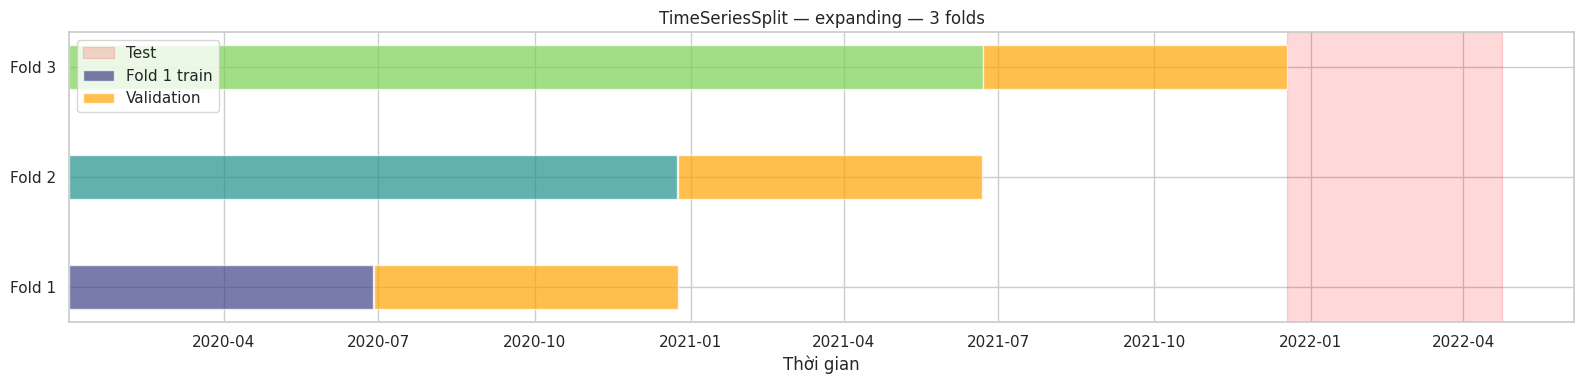

Biểu đồ trực quan hoá các fold trên trục thời gian.


In [11]:
fig, ax = plt.subplots(figsize=(16, 4))

# Vẽ test region
ax.axvspan(test_ts.iloc[0], test_ts.iloc[-1], alpha=0.15, color="red", label="Test")

# Vẽ từng fold
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(folds)))
for i, f in enumerate(folds):
    y = i + 1
    ax.barh(y, (f["train_end_ts"] - f["train_start_ts"]).days,
            left=f["train_start_ts"], height=0.4, color=colors[i], alpha=0.7,
            label=f"Fold {f['fold']} train" if i == 0 else None)
    ax.barh(y, (f["val_end_ts"] - f["val_start_ts"]).days,
            left=f["val_start_ts"], height=0.4, color="orange", alpha=0.7,
            label="Validation" if i == 0 else None)

ax.set_yticks(range(1, len(folds) + 1))
ax.set_yticklabels([f"Fold {f['fold']}" for f in folds])
ax.set_xlabel("Thời gian")
ax.set_title(f"TimeSeriesSplit — {STRATEGY} — {N_SPLITS} folds")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()
print("Biểu đồ trực quan hoá các fold trên trục thời gian.")

## 11. Tạo DataFrame cho từng fold và compatibility alias
*Nguồn tham chiếu:* `notebooks/split_and_feature/01_slip_time_series.ipynb` → hàm `filter_window()` và phần `run_split()` gán `train_alias`, `val_alias`  
Filter dữ liệu theo cửa sổ timestamp cho từng fold. Fold cuối = alias cho train/val.

In [12]:
# Hàm filter theo cửa sổ timestamp
def filter_window(df, start_ts, end_ts):
    """Lọc dữ liệu trong cửa sổ [start_ts, end_ts]."""
    mask = (df[TIMESTAMP_COL] >= start_ts) & (df[TIMESTAMP_COL] <= end_ts)
    return df.loc[mask].copy(deep=False)

# Compatibility alias từ fold cuối
final_fold = folds[-1]
train_alias = filter_window(df, final_fold["train_start_ts"], final_fold["train_end_ts"])
val_alias = filter_window(df, final_fold["val_start_ts"], final_fold["val_end_ts"])

train_alias[f"{VERSION}_split"] = "train"
val_alias[f"{VERSION}_split"] = "val"
test[f"{VERSION}_split"] = "test"

print(f"Final fold (fold {final_fold['fold']}):")
print(f"  Train: {final_fold['train_start_ts']} → {final_fold['train_end_ts']} ({len(train_alias):,} dòng)")
print(f"  Val  : {final_fold['val_start_ts']} → {final_fold['val_end_ts']} ({len(val_alias):,} dòng)")
print(f"  Test : {test_ts.iloc[0]} → {test_ts.iloc[-1]} ({len(test):,} dòng)")

Final fold (fold 3):
  Train: 2020-01-01 00:15:00 → 2021-06-22 01:00:00 (1,550,856 dòng)
  Val  : 2021-06-22 01:15:00 → 2021-12-18 09:15:00 (723,114 dòng)
  Test : 2021-12-18 09:30:00 → 2022-04-23 23:45:00 (510,468 dòng)


## 12. Tổng kết split (Split Summary)
*Nguồn tham chiếu:* `notebooks/split_and_feature/01_slip_time_series.ipynb` → hàm `summarize_part()`

In [13]:
# Hàm tổng kết
def summarize_part(name, part, fold=None, role=None):
    """Tạo dict tổng kết cho 1 phần dữ liệu."""
    row = {
        "name": name,
        "rows": int(len(part)),
        "site_count": int(part[SITE_COL].nunique()) if SITE_COL in part else 0,
        "min_timestamp": part[TIMESTAMP_COL].min() if len(part) else pd.NaT,
        "max_timestamp": part[TIMESTAMP_COL].max() if len(part) else pd.NaT,
        "target_null_rows": int(part[TARGET_COL].isna().sum()) if TARGET_COL in part else 0,
    }
    if fold is not None:
        row["fold"] = fold
    if role is not None:
        row["role"] = role
    for col in (
        f"{VERSION}_missing_weather_flag",
        f"{VERSION}_outlier_flag",
        f"{VERSION}_exclude_from_loss_flag",
        f"{VERSION}_has_complete_history_features",
        f"{VERSION}_gap_after_prev_flag",
    ):
        if col in part.columns:
            row[col] = int(part[col].fillna(False).sum())
    return row

split_summary = pd.DataFrame([
    summarize_part("development", development),
    summarize_part("train_alias_final_fold", train_alias),
    summarize_part("val_alias_final_fold", val_alias),
    summarize_part("test", test),
])


fold_rows = []
for f in folds:
    fold_train = filter_window(df, f["train_start_ts"], f["train_end_ts"])
    fold_val = filter_window(df, f["val_start_ts"], f["val_end_ts"])
    fold_rows.append(summarize_part(f"fold_{f['fold']}_train", fold_train, fold=f['fold'], role='train'))
    fold_rows.append(summarize_part(f"fold_{f['fold']}_val", fold_val, fold=f['fold'], role='val'))
    del fold_train, fold_val

fold_detail = pd.DataFrame(fold_rows)
print("\n--- FOLD DETAIL ---")
display(fold_detail)



--- FOLD DETAIL ---


,name,rows,site_count,min_timestamp,max_timestamp,target_null_rows,fold,role
0,fold_1_train,233244,30,2020-01-01 00:15:00,2020-06-28 08:30:00,0,1,train
1,fold_1_val,606105,39,2020-06-28 08:45:00,2020-12-24 16:45:00,0,1,val
2,fold_2_train,839349,39,2020-01-01 00:15:00,2020-12-24 16:45:00,0,2,train
3,fold_2_val,711507,42,2020-12-24 17:00:00,2021-06-22 01:00:00,0,2,val
4,fold_3_train,1550856,42,2020-01-01 00:15:00,2021-06-22 01:00:00,0,3,train
5,fold_3_val,723114,42,2021-06-22 01:15:00,2021-12-18 09:15:00,0,3,val


## 13. Export
*Nguồn tham chiếu:* `notebooks/split_and_feature/01_slip_time_series.ipynb` → phần `run_split()` lưu parquet và CSV summary  
Lưu development, test, từng fold, alias train/val, và summary.

In [14]:
from pathlib import Path

out_dir = Path(OUTPUT_DIR)

# Tạo thư mục
for sub in ["development", "test", "final_train", "train", "val",
            "time_series_folds", "summaries"]:
    (out_dir / sub).mkdir(parents=True, exist_ok=True)

# Lưu development, test, final_train
development.to_parquet(out_dir / "development" / f"{VERSION}_development.parquet", index=False)
test.to_parquet(out_dir / "test" / f"{VERSION}_test.parquet", index=False)
development.to_parquet(out_dir / "final_train" / f"{VERSION}_final_train.parquet", index=False)

# Lưu train/val alias (từ fold cuối)
train_alias.to_parquet(out_dir / "train" / f"{VERSION}_train.parquet", index=False)
val_alias.to_parquet(out_dir / "val" / f"{VERSION}_val.parquet", index=False)

# Lưu từng fold
for f in folds:
    fold_n = f["fold"]
    ft = filter_window(df, f["train_start_ts"], f["train_end_ts"])
    fv = filter_window(df, f["val_start_ts"], f["val_end_ts"])
    ft[f"{VERSION}_cv_fold"] = fold_n
    ft[f"{VERSION}_cv_role"] = "train"
    fv[f"{VERSION}_cv_fold"] = fold_n
    fv[f"{VERSION}_cv_role"] = "val"
    ft.to_parquet(out_dir / "time_series_folds" / f"fold_{fold_n}_train.parquet", index=False)
    fv.to_parquet(out_dir / "time_series_folds" / f"fold_{fold_n}_val.parquet", index=False)
    del ft, fv

# Lưu summaries
split_summary.to_csv(out_dir / "summaries" / f"{VERSION}_split_summary.csv", index=False)
fold_detail.to_csv(out_dir / "summaries" / f"{VERSION}_time_series_fold_summary.csv", index=False)

print(f"Đã lưu tất cả output vào: {OUTPUT_DIR}")
print(f"  development : {len(development):,} dòng")
print(f"  test        : {len(test):,} dòng")
print(f"  train alias : {len(train_alias):,} dòng (fold {final_fold['fold']})")
print(f"  val alias   : {len(val_alias):,} dòng (fold {final_fold['fold']})")
print(f"  folds       : {len(folds)} folds × 2 parquet")
print("Hoàn tất Notebook 02 — Split Time-Series Data!")

Đã lưu tất cả output vào: ../../data/model/v4/02_split
  development : 2,273,970 dòng
  test        : 510,468 dòng
  train alias : 1,550,856 dòng (fold 3)
  val alias   : 723,114 dòng (fold 3)
  folds       : 3 folds × 2 parquet
Hoàn tất Notebook 02 — Split Time-Series Data!
